# ETF trend

A monthly long/cash strategy across ten GBP ETF's. The selected six-month rule earned more than a fixed passive/cash benchmark in the reserved period, but also took more risk. Fully invested buy-and-hold returned more than either.

This strategy is unlikely to implemented in practice due to it being outperformed by a standard 'buy and hold' over the same universe and time period, even before portfolio optimisation techniques. All results included (modelled) transaction costs. This notebook provides a useful summary, with the full research being available in the [original notebook](archive/etf_trend_research_2026_09_16.ipynb).

The economic hypothesis is the following. Gradual responses to information, and persistent flow of investment could lead to sustained trends across equity, bond and commodity markets. A long/cash rule could (in theory) participate when markets are performing well, and reduce exposure during troughs.

This is motivated by [time-series momentum research](https://www.aqr.com/Insights/Research/Journal-Article/Time-Series-Momentum), not a replication of its futures/forwards strategy.

Assets tested cover global underlying assets. UK listing currency does not remove underlying currency exposure. The present-day selection is not a historical membership database, and ten instruments do not represent ten independent risks.

### Imports and setup

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

candidates = [candidate for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents) for candidate in (base, base / "etf_trend", base / "trading_portfolio" / "etf_trend")]
PROJECT_ROOT = next(p for p in candidates if (p / "src" / "etf_research.py").is_file())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import etf_research
import etf_validation
import etf_plotting

%matplotlib inline

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Strategy began using 12 month return data, where if a given equity's returns were positive over the past 12 months, we would rebalance to have 10% of that asset in our portfolio. If returns were negative over that period, that '10%' would remain in cash. Development period compared 3, 6, 9 and 12 month lookbacks, with 6 month being selected. The benchmark holds 55.6653% in the equal-weight basket (6m development volatility divided by fully invested volatility), with the remainder in cash. It is fixed and not recalibrated to the realised risk. Settings below were fixed during the original research notebook.

In [ ]:
DATA_START = "2000-01-01"  
DATA_END = "2026-09-01"    #date is exclusive
ANALYSIS_START = "2017-04-10"
HOLDOUT_START = "2023-01-01"
LOOKBACK_MONTHS = (3, 6, 9, 12)

BACKTEST = {
    "initial_capital_gbp": 10_000.0,
    "cost_per_side_bps": 10.0,
    "cash_rate_annual": 0.0
}

FINAL_SPEC = {
    "lookback_months": 6,
    "passive_fraction": 0.5566532251165176,
    "holdout_start": HOLDOUT_START,
    "holdout_end_exclusive": DATA_END,
    **BACKTEST
}

EVALUATION_SETTINGS = {
    "bootstrap_block_months": 3,
    "bootstrap_samples": 10_000,
    "confidence_level": 0.95,
    "seed": 42,
    "cost_scenarios_bps": (5.0, 10.0, 20.0)
}

QUOTE_EXCLUSIONS = {"IJPN": ["2025-10-24"], "CMOP": ["2025-10-24"]}
universe = etf_research.study_universe()
display(universe[["exposure", "instrument_type", "replication", "share_class"]])

,exposure,instrument_type,replication,share_class
ticker,,,,
IUSA,US equities,ETF,physical,Dist
ISF,UK equities,ETF,physical,Dist
IEUX,Europe excluding UK equities,ETF,physical,Dist
IJPN,Japan equities,ETF,physical,Dist
IEEM,Emerging-market equities,ETF,physical,Dist
IGLT,UK conventional gilts,ETF,physical,Dist
INXG,UK inflation-linked gilts,ETF,physical,Dist
SLXX,GBP corporate bonds,ETF,physical,Dist
SGLN,Physical gold,ETC,physical_metal,No income


This is our chosen universe.

Now we fix the defects in our data set. Raw equity histories raised an issue with dividends being measured in pence as opposed to GBP, which is repaired in the dataset today. Common history starts on 10/04/2017.

There are two unreliable quotes (IJPN, CMOP on 24/10/2025) which remain excluded from input prices. Portfolio valuation uses preceding session's adjusted close as neither are a signal month-end or a rebalance date, preserving the monthly endpoints under our trading rule, but daily risk around here is approximate.



In [ ]:
data = etf_research.prepare_cached_data(
    PROJECT_ROOT, universe,
    data_start=DATA_START, data_end=DATA_END,
    analysis_start=ANALYSIS_START, holdout_start=HOLDOUT_START,
    quote_exclusions=QUOTE_EXCLUSIONS
)

display(data["audit"].round(4))
display(data["period_summary"])
print("Month-end prices:", data["monthly_prices"].shape)

,raw_currency,repaired_currency,raw_adjustment_ratio,repaired_adjustment_ratio,sessions,excluded_quotes
ticker,,,,,,
IUSA,GBp,GBP,0.01,1.0,2371,0
ISF,GBp,GBP,0.01,1.0,2371,0
IEUX,GBp,GBP,0.01,1.0,2371,0
IJPN,GBp,GBP,0.01,1.0,2371,1
IEEM,GBp,GBP,0.01,1.0,2371,0
IGLT,GBP,GBP,1.00,1.0,2371,0
INXG,GBP,GBP,1.00,1.0,2371,0
SLXX,GBP,GBP,1.00,1.0,2371,0
SGLN,GBp,GBP,NaN,NaN,2371,0


,first_execution,last_execution,rebalances
period,,,
development,2018-05-01,2022-12-01,56
holdout,2023-01-03,2026-08-03,44


Month-end prices: (113, 10)


## Development

At the final London session close of month $t$, calculate

$$
r_{i,t}^{(L)} = \frac{P^{adj}_{i,t}}{P^{adj}_{i,t-L}} - 1,\qquad w_{i,t} = \frac{1}{10}\mathbf{1}\{r_{i,t}^{(L)} > 0\}
$$

which is a (perhaps overly ellaborate) way of expressing what the signal does, with the LHS being the returns over the given lookback, and the right hand side being the weight for each asset (recall $\mathbf{1}_{A}$ is the indicator function of a set $A$). As implied in the formula, if $r_{i,t}^{(L)} < 0$, then that asset's budget remains in cash and active positions (where an assets returns are positive) are NOT rescaled to account for this. Rebalancing occurs at the following session open, with weights drifting until the next (monthly) rebalance. Development period spans 01/05/2018-30/12/2022, with the remainder being a holdout period.

Adjusted opens equal $\frac{\text{Open } \times \text{ Adj Close }}{\text{Close}}$, with synthetic adjusted price units embedding divident adjustments. Both sides of the trade occur modelled trading costs (including intital purchase). Cash earns no interest over this time, and final valuation does not require liquidating the portfolio. All trades are modelled as assumed fills with transaction costs.


In [ ]:
sweep_summary, sweep_results, development_benchmarks = etf_research.run_development(data, LOOKBACK_MONTHS, BACKTEST)
display(sweep_summary.round(2))

development_comparison = {
    "Original 12-month rule": sweep_results[12],
    "Monthly equal weight": development_benchmarks["monthly_equal_weight"],
    "Buy and hold": development_benchmarks["buy_and_hold"]
}
display(etf_research.summarise_portfolios(development_comparison, BACKTEST["initial_capital_gbp"]).round(2))

,final_value_gbp,cagr_pct,annualised_vol_pct,max_drawdown_pct,mean_cash_pct,total_cost_gbp,rebalances
lookback_months,,,,,,,
3,11437.79,2.92,5.67,-7.52,41.13,152.06,56
6,11517.42,3.07,5.39,-6.38,40.60,109.65,56
9,10806.42,1.68,5.82,-10.28,38.23,99.31,56
12,11106.63,2.27,6.23,-11.88,35.09,87.31,56


,final_value_gbp,total_return_pct,cagr_pct,annualised_vol_pct,max_drawdown_pct,mean_cash_pct,total_cost_gbp
portfolio,,,,,,,
Original 12-month rule,11106.63,11.07,2.27,6.23,-11.88,35.09,87.31
Monthly equal weight,11959.68,19.60,3.91,9.68,-16.84,0.00,25.33
Buy and hold,12001.16,20.01,3.99,9.51,-16.36,0.00,9.99


See that of all methods testing, the 6m lookback period is the best performing by returns, CAGFR and has the smallest max drawdown across the candidates. This strategy is fixed for the holdout.

Compare the strategy with the fixed monthly passive/cash portfolio, with both starting on 03/01/2023 with £10,000, and ending on 28/08/2026. The fully invested buy and hold approach is included as a comparison after primary results were inspected (buy equal allocations across each asset and allow them to drift).

In [ ]:
development_fraction = sweep_results[FINAL_SPEC["lookback_months"]]["daily"]["net_return"].std(ddof=1) / development_benchmarks["monthly_equal_weight"]["daily"]["net_return"].std(ddof=1)
assert np.isclose(development_fraction, FINAL_SPEC["passive_fraction"], rtol=0, atol=1e-12)
display(pd.Series(FINAL_SPEC, name="frozen_specification"))

holdout_inputs = etf_research.period_inputs(data, "holdout")
holdout_results = etf_validation.run_frozen_evaluation(**holdout_inputs, spec=FINAL_SPEC)
buy_and_hold = etf_research.run_buy_and_hold(holdout_inputs, BACKTEST)
comparison_results = {
    "Trend (6 months)": holdout_results["trend"],
    "Passive + cash": holdout_results["passive_cash"],
    "Buy and hold": buy_and_hold
}
holdout_summary = etf_research.summarise_portfolios(comparison_results, FINAL_SPEC["initial_capital_gbp"])
display(holdout_summary.round(2))

lookback_months                   6
passive_fraction           0.556653
holdout_start            2023-01-01
holdout_end_exclusive    2026-09-01
initial_capital_gbp         10000.0
cost_per_side_bps              10.0
cash_rate_annual                0.0
Name: frozen_specification, dtype: object

,final_value_gbp,total_return_pct,cagr_pct,annualised_vol_pct,max_drawdown_pct,mean_cash_pct,total_cost_gbp
portfolio,,,,,,,
Trend (6 months),13325.30,33.25,8.18,6.10,-6.95,26.99,93.45
Passive + cash,12462.23,24.62,6.21,4.16,-5.01,44.24,11.15
Buy and hold,15077.45,50.77,11.90,8.00,-9.09,0.00,9.99


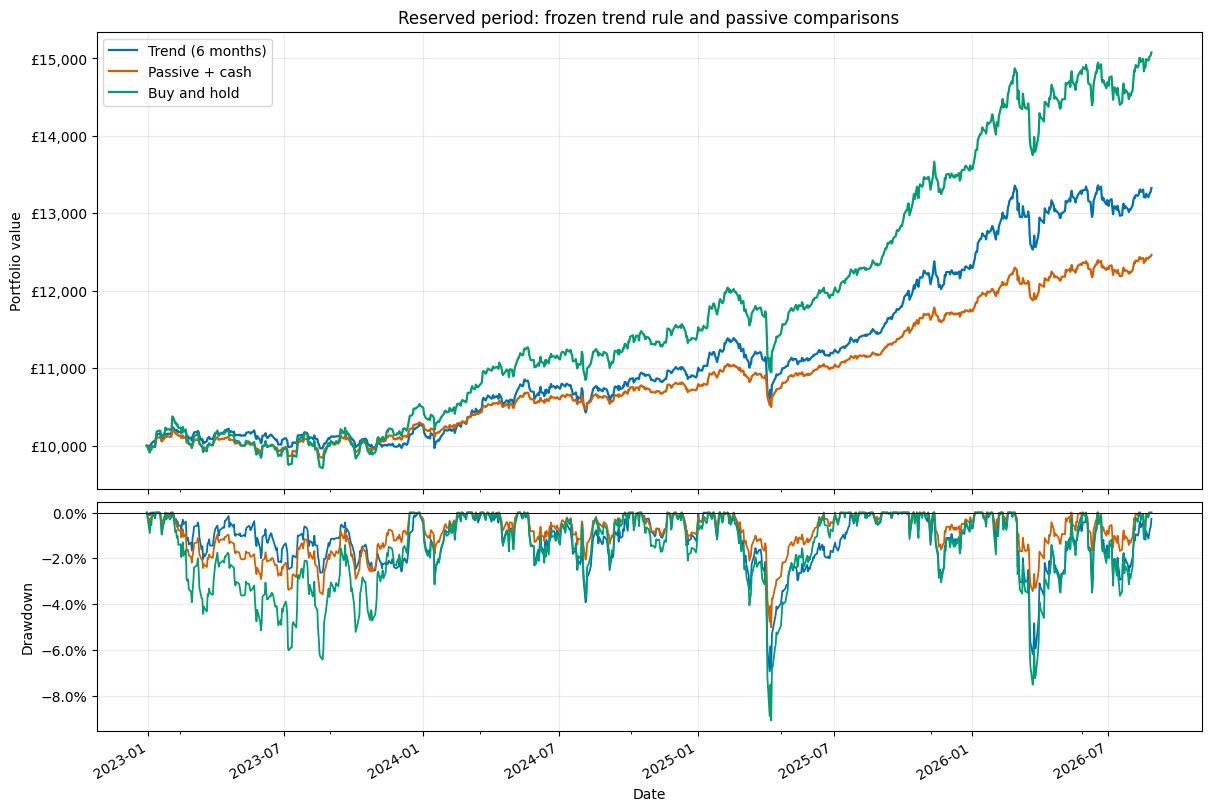

In [ ]:
holdout_equity = pd.DataFrame({name: result["daily"]["nav_close"] for name, result in comparison_results.items()})
fig, axes = etf_plotting.plot_equity_and_drawdown(holdout_equity,
    initial_capital_gbp=FINAL_SPEC["initial_capital_gbp"],
    start_date=holdout_inputs["decision_schedule"].index[0],
    title="Reserved period: frozen trend rule and passive comparisons"
)
image_directory = PROJECT_ROOT / "images"
image_directory.mkdir(exist_ok=True)
fig.savefig(image_directory / "holdout_equity_drawdown.png", dpi=150, bbox_inches="tight")

The trend portfolio ends at £13,325, compared with £12,462 for passive + cash and £15,077 for buy and hold. Trend's annualised volatility is 6.10%, laying between the two passive portfolios (4.16% and 8.00%). Its drawdown is also between theirs. Higher returns relative to the cash-composite benchmark therefore does not, alone, establish an improvement after allowing for risk.

Now compound each portfolio's daily net returns into calendar months, then subtract benchmark from strategy. The test concerns mean monthly net excess. Use 3 month circular blocks and 10000 samples. Resample the paired monthly difference, centre it under the zero-mean null, and report a one-sided p-value and two-sided bootstrap confidence interval. Dependence beyond the chosen blocks and changes in the return distribution remain limitations. [Bootstrap method](https://bashtage.github.io/arch/bootstrap/timeseries-bootstraps.html).

In [ ]:
holdout_returns = pd.DataFrame({name: result["daily"]["net_return"] for name, result in holdout_results.items()})
assert holdout_returns.index.equals(holdout_inputs["open_prices"].index)
assert np.isfinite(holdout_returns.to_numpy()).all()
holdout_monthly_returns = ((1 + holdout_returns).groupby(holdout_returns.index.to_period("M")).prod() - 1)
holdout_monthly_excess = (holdout_monthly_returns["trend"] - holdout_monthly_returns["passive_cash"]).rename("net_excess")
holdout_inference = etf_validation.bootstrap_mean_excess(holdout_monthly_excess,
    block_months=EVALUATION_SETTINGS["bootstrap_block_months"],
    n_bootstrap=EVALUATION_SETTINGS["bootstrap_samples"],
    confidence_level=EVALUATION_SETTINGS["confidence_level"],
    seed=EVALUATION_SETTINGS["seed"])
display(holdout_inference.round(4))

months                     44.0000
mean_monthly_excess_bps    16.0797
lower_ci_bps               -2.6714
upper_ci_bps               32.8439
one_sided_p_value           0.0448
dtype: float64

Mean monthly net excess is 16.08 bp, with a two-sided 95% interval of [−2.67, 32.84] bp and one-sided p = 0.0448. See the interval contains 0 narrowly, so no advantage shown there. However, our p-value falls under the 5% threshold, hence there is significance of the monthly excess between our method and the cash-composite benchmark. 

This is limited evidence of positive mean excess against the specified passive/cash benchmark. It neither proves that the economic mechanism caused the return nor establishes a compelling reason to trade the strategy.

Now test the portfolio sensitivity to transaction costs. Rerun both portfolios at 5, 10, 20bp per side, including their actual turnover. 10bp remains the primary assumption.

In [ ]:
holdout_cost_summary, holdout_cost_runs = etf_validation.run_cost_sensitivity(**holdout_inputs, spec=FINAL_SPEC, evaluation_settings=EVALUATION_SETTINGS)
for name, original in holdout_results.items():
    pd.testing.assert_frame_equal(holdout_cost_runs[FINAL_SPEC["cost_per_side_bps"]][name]["daily"], original["daily"])
display(holdout_cost_summary[["trend_final_gbp", "benchmark_final_gbp", "mean_monthly_excess_bps", "lower_ci_bps", "upper_ci_bps", "one_sided_p_value"]].round(4))

,trend_final_gbp,benchmark_final_gbp,mean_monthly_excess_bps,lower_ci_bps,upper_ci_bps,one_sided_p_value
cost_per_side_bps,,,,,,
5.0,13382.1939,12468.8774,16.9333,-1.6961,33.5820,0.0364
10.0,13325.2997,12462.2332,16.0797,-2.6714,32.8439,0.0448
20.0,13212.2304,12448.9580,14.3727,-4.6382,31.3524,0.0670


The strategy remains ahead of passive + cash benchmarks across the three cost scenarios. However, one-sided p-values move from 0.0364 at 5 bp to 0.0670 at 20 bp, so the significance label is sensitive to transaction costs, even though the wealth results change gradually.

Our six month rule has reduced realised volatility and drawdown relative to the (fully-invested) buy and hold approach, but at the cost of returns. When pitched against the cash-composite benchmark, it improved returns at the cost of risk. This project has not established sufficient evidence to justify implementing this strategy. 

Conclusion is limited by a present-day universe (hence elements of suvivorship bias), correlated asset exposures, and a relatively small holdout period at 44 months. In each scenario, all cash earned no interest, should not be interpreted as a historical cash-rate comparison. 